Exploratory Data Analysis

In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Better chart size
plt.rcParams["figure.figsize"] = (10,5)

In [3]:
#Load Dataset
df = pd.read_csv("ola_feature_engineered.csv")

In [5]:
# Convert Date back to datetime
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Driver Ratings,Customer Rating,Year,Quarter,Month,Month Name,Day,Day Name,Hour,Time Slot
0,2024-01-28,1900-01-01 06:00:00,CNR1721175,Success,329258,Auto,Area-3,Area-2,5.42,18.46,...,4.4,4.4,2024,1,1,January,28,Sunday,6,Morning
1,2024-01-26,1900-01-01 03:00:00,CNR2871422,Cancelled by Driver,201414,Mini,Area-7,Area-6,NaN,NaN,...,NaN,NaN,2024,1,1,January,26,Friday,3,Night
2,2024-01-15,1900-01-01 16:00:00,CNR6875935,Cancelled by Driver,301629,Bike,Area-40,Area-24,NaN,NaN,...,NaN,NaN,2024,1,1,January,15,Monday,16,Afternoon
3,2024-01-02,1900-01-01 22:00:00,CNR6798834,Cancelled by Driver,319684,Prime Sedan,Area-11,Area-24,NaN,NaN,...,NaN,NaN,2024,1,1,January,2,Tuesday,22,Night
4,2024-01-30,1900-01-01 22:00:00,CNR9661713,Incomplete,330283,Bike,Area-41,Area-45,NaN,NaN,...,NaN,NaN,2024,1,1,January,30,Tuesday,22,Night


In [6]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Rows : 49999
Columns : 29
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date                               49999 non-null  datetime64[ns]
 1   Time                               49999 non-null  object        
 2   Booking ID                         49999 non-null  object        
 3   Booking Status                     49999 non-null  object        
 4   Customer ID                        49999 non-null  int64         
 5   Vehicle Type                       49999 non-null  object        
 6   Pickup Location                    49999 non-null  object        
 7   Drop Location                      49999 non-null  object        
 8   Avg VTAT                           33484 non-null  float64       
 9   Avg CTAT                           33484 non-null  float64       
 10  Cancelle

In [7]:
df.describe(include="all")

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Driver Ratings,Customer Rating,Year,Quarter,Month,Month Name,Day,Day Name,Hour,Time Slot
count,49999,49999,49999,49999,49999.000000,49999,49999,49999,33484.000000,33484.000000,...,33484.00000,33484.000000,49999.0,49999.0,49999.0,49999,49999.000000,49999,49999.000000,49999
unique,NaN,24,49866,4,NaN,7,50,50,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,NaN,7,NaN,4
top,NaN,1900-01-01 00:00:00,CNR1569898,Success,NaN,Prime Plus,Area-39,Area-39,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,January,NaN,Monday,NaN,Night
freq,NaN,2171,2,33484,NaN,7252,1100,1058,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,49999,NaN,8324,NaN,16698
mean,2024-01-15 12:52:56.991539968,NaN,NaN,NaN,550979.937539,NaN,NaN,NaN,10.481654,15.564320,...,4.00304,4.001726,2024.0,1.0,1.0,NaN,15.536771,NaN,11.474289,NaN
min,2024-01-01 00:00:00,NaN,NaN,NaN,100001.000000,NaN,NaN,NaN,1.000000,1.000000,...,3.00000,3.000000,2024.0,1.0,1.0,NaN,1.000000,NaN,0.000000,NaN
25%,2024-01-08 00:00:00,NaN,NaN,NaN,328740.500000,NaN,NaN,NaN,5.730000,8.310000,...,3.50000,3.500000,2024.0,1.0,1.0,NaN,8.000000,NaN,5.000000,NaN
50%,2024-01-15 00:00:00,NaN,NaN,NaN,552598.000000,NaN,NaN,NaN,10.460000,15.610000,...,4.00000,4.000000,2024.0,1.0,1.0,NaN,15.000000,NaN,12.000000,NaN
75%,2024-01-23 00:00:00,NaN,NaN,NaN,773970.000000,NaN,NaN,NaN,15.240000,22.790000,...,4.50000,4.500000,2024.0,1.0,1.0,NaN,23.000000,NaN,17.000000,NaN
max,2024-01-31 00:00:00,NaN,NaN,NaN,999991.000000,NaN,NaN,NaN,20.000000,30.000000,...,5.00000,5.000000,2024.0,1.0,1.0,NaN,31.000000,NaN,23.000000,NaN


Booking Status Distribution

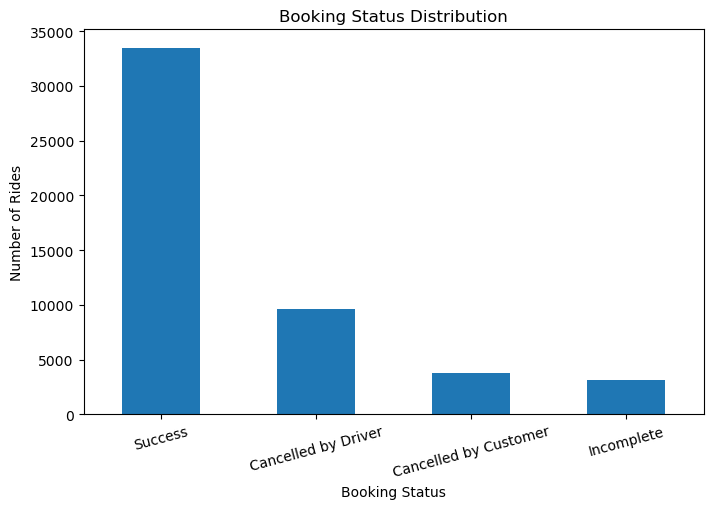

Booking Status
Success                  33484
Cancelled by Driver       9610
Cancelled by Customer     3799
Incomplete                3106
Name: count, dtype: int64


In [8]:
booking_counts = df["Booking Status"].value_counts()

plt.figure(figsize=(8,5))
booking_counts.plot(kind="bar")

plt.title("Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Number of Rides")

plt.xticks(rotation=15)
plt.show()

print(booking_counts)

Insight:

1. Majority of rides are successful.
2. Driver cancellations are higher than customer cancellations.
3. Incomplete rides account for a smaller portion.

Vehicle Type Popularity

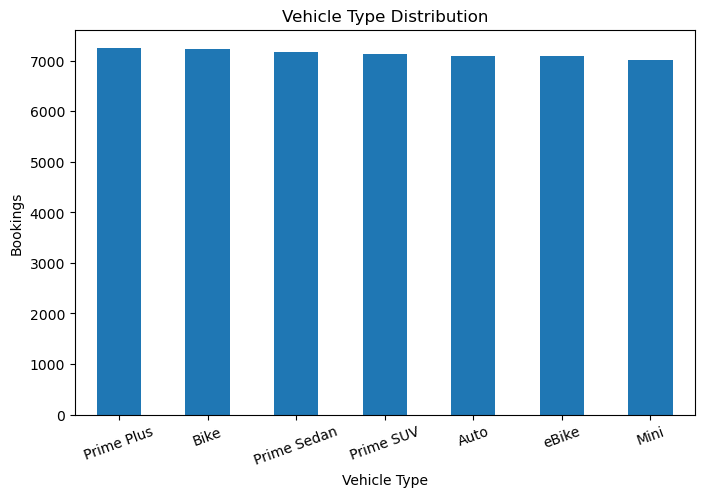

Vehicle Type
Prime Plus     7252
Bike           7223
Prime Sedan    7179
Prime SUV      7140
Auto           7098
eBike          7097
Mini           7010
Name: count, dtype: int64


In [9]:
vehicle_counts = df["Vehicle Type"].value_counts()

plt.figure(figsize=(8,5))
vehicle_counts.plot(kind="bar")

plt.title("Vehicle Type Distribution")
plt.xlabel("Vehicle Type")
plt.ylabel("Bookings")

plt.xticks(rotation=20)

plt.show()

print(vehicle_counts)

Insight:

Identify the most and least booked vehicle categories.

Payment Method Analysis

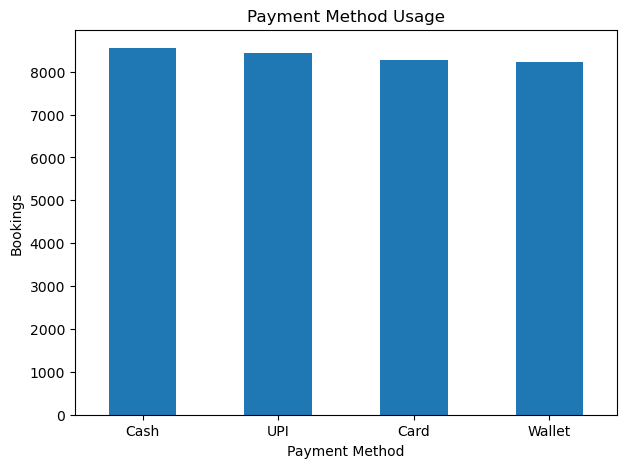

Payment Method
Cash      8552
UPI       8428
Card      8280
Wallet    8224
Name: count, dtype: int64


In [10]:
payment_counts = df["Payment Method"].value_counts()

plt.figure(figsize=(7,5))
payment_counts.plot(kind="bar")

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Bookings")

plt.xticks(rotation=0)

plt.show()

print(payment_counts)

Insight:

1. Compare Cash, UPI, Wallet, and Card usage.
2. Note that successful rides mainly contribute to payment data.

Monthly Bookings

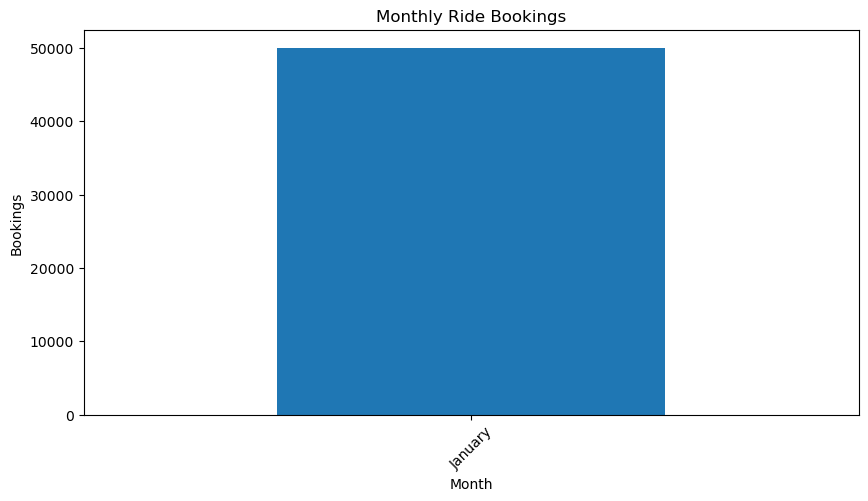

Month Name
January    49999.0
dtype: float64


In [12]:
monthly = df.groupby("Month Name").size()

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly = monthly.reindex(month_order).dropna()

plt.figure(figsize=(10,5))
monthly.plot(kind="bar")

plt.title("Monthly Ride Bookings")
plt.xlabel("Month")
plt.ylabel("Bookings")

plt.xticks(rotation=45)

plt.show()

print(monthly)

Bookings by Day of Week

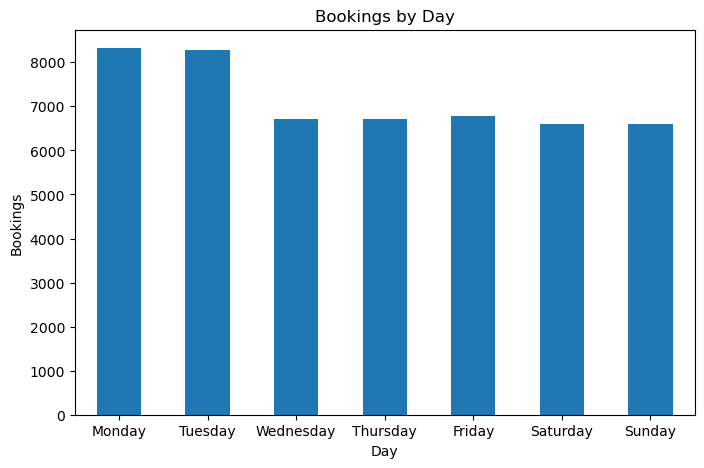

Day Name
Monday       8324
Tuesday      8283
Wednesday    6717
Thursday     6703
Friday       6771
Saturday     6597
Sunday       6604
Name: count, dtype: int64


In [13]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

days = df["Day Name"].value_counts().reindex(day_order)

plt.figure(figsize=(8,5))
days.plot(kind="bar")

plt.title("Bookings by Day")
plt.xlabel("Day")
plt.ylabel("Bookings")

plt.xticks(rotation=0)

plt.show()

print(days)

Insight:

Identify peak weekdays and weekends.

Bookings by Time Slot

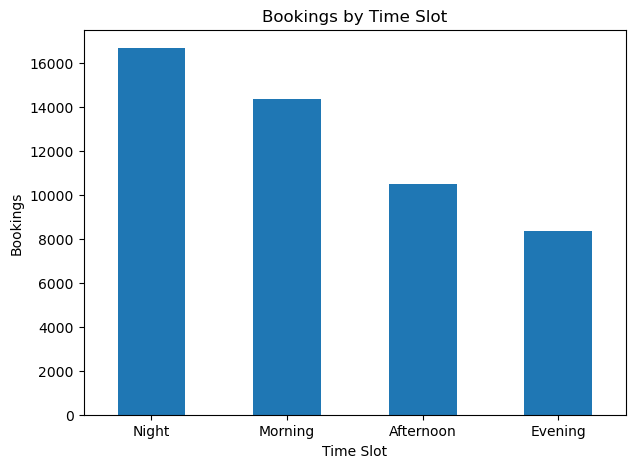

Time Slot
Night        16698
Morning      14388
Afternoon    10527
Evening       8386
Name: count, dtype: int64


In [15]:
slot = df["Time Slot"].value_counts()

plt.figure(figsize=(7,5))
slot.plot(kind="bar")

plt.title("Bookings by Time Slot")
plt.xlabel("Time Slot")
plt.ylabel("Bookings")

plt.xticks(rotation=0)

plt.show()

print(slot)

Insight:

Determine whether demand is highest in the morning, afternoon, evening, or night.

Booking Value Analysis

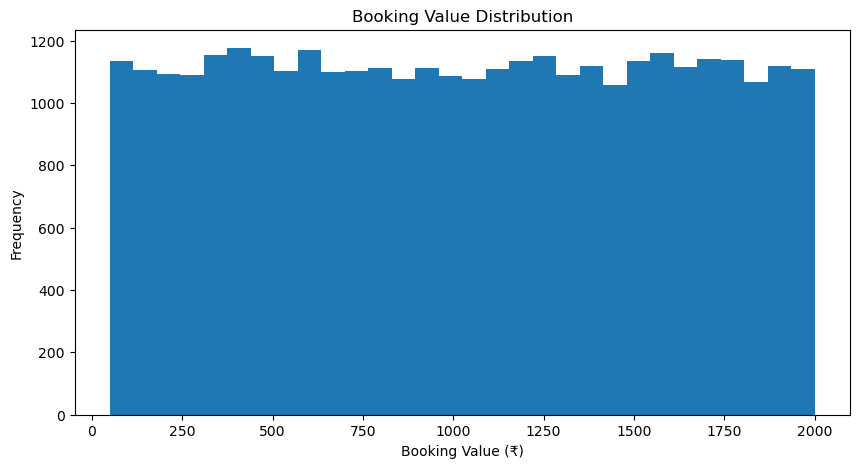

Average Booking Value: 1023.37
Maximum Booking Value: 2000.0
Minimum Booking Value: 50.1


In [21]:
booking_value = df["Booking Value"].dropna()

plt.figure(figsize=(10,5))
plt.hist(booking_value, bins=30)

plt.title("Booking Value Distribution")
plt.xlabel("Booking Value (₹)")
plt.ylabel("Frequency")

plt.show()

print("Average Booking Value:", round(booking_value.mean(), 2))
print("Maximum Booking Value:", booking_value.max())
print("Minimum Booking Value:", booking_value.min())

Ride Distance Analysis

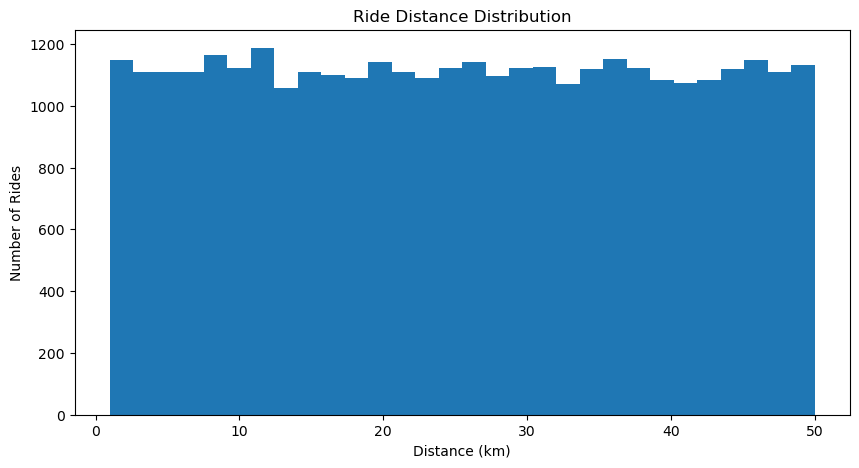

Average Distance: 25.45
Max Distance: 50.0


In [22]:
ride_distance = df["Ride Distance"].dropna()

plt.figure(figsize=(10,5))
plt.hist(ride_distance, bins=30)

plt.title("Ride Distance Distribution")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Rides")

plt.show()

print("Average Distance:", round(ride_distance.mean(), 2))
print("Max Distance:", ride_distance.max())

Revenue by Vehicle Type

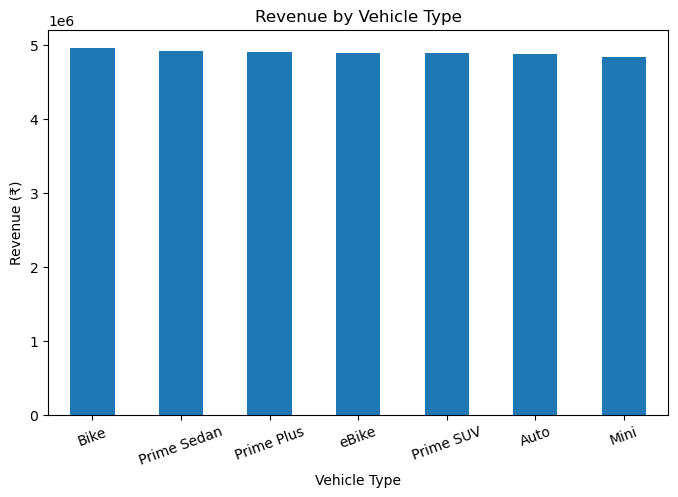

Vehicle Type
Bike           4957790.69
Prime Sedan    4919408.86
Prime Plus     4906974.66
eBike          4886694.02
Prime SUV      4884966.98
Auto           4870612.58
Mini           4840216.80
Name: Booking Value, dtype: float64


In [23]:
vehicle_revenue = (
    df.groupby("Vehicle Type")["Booking Value"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
vehicle_revenue.plot(kind="bar")

plt.title("Revenue by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=20)

plt.show()

print(vehicle_revenue)

Average Fare by Vehicle Type

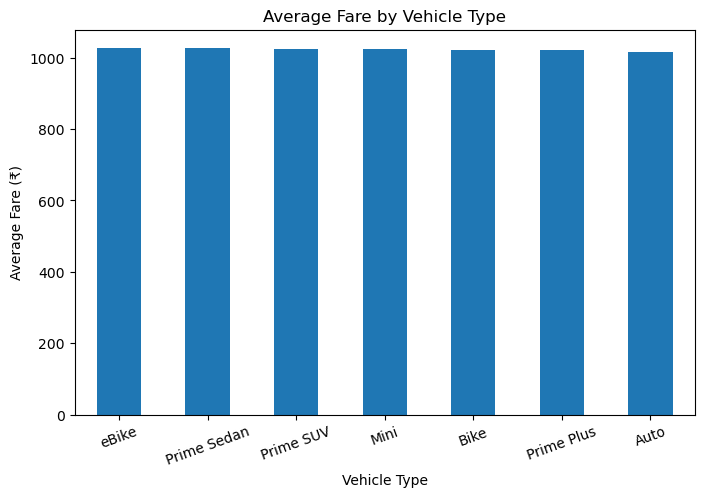

Vehicle Type
eBike          1027.479819
Prime Sedan    1027.016463
Prime SUV      1024.746587
Mini           1024.167753
Bike           1021.592971
Prime Plus     1021.435192
Auto           1017.254089
Name: Booking Value, dtype: float64


In [24]:
avg_fare = (
    df.groupby("Vehicle Type")["Booking Value"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
avg_fare.plot(kind="bar")

plt.title("Average Fare by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Fare (₹)")

plt.xticks(rotation=20)

plt.show()

print(avg_fare)

Driver Rating Analysis

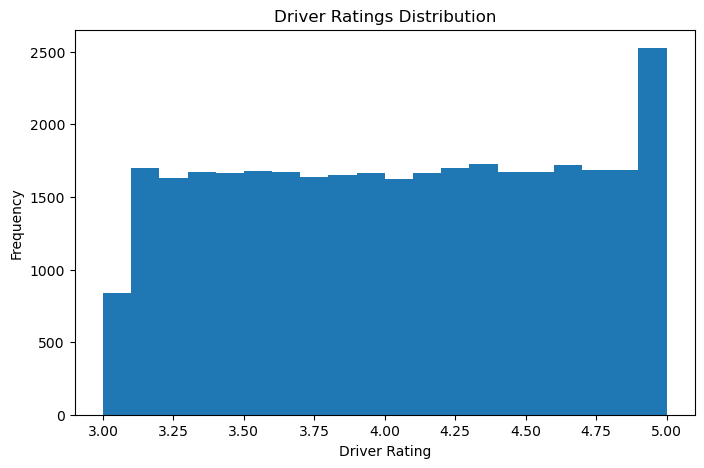

Average Driver Rating: 4.0


In [25]:
driver_rating = df["Driver Ratings"].dropna()

plt.figure(figsize=(8,5))
plt.hist(driver_rating, bins=20)

plt.title("Driver Ratings Distribution")
plt.xlabel("Driver Rating")
plt.ylabel("Frequency")

plt.show()

print("Average Driver Rating:", round(driver_rating.mean(),2))

Customer Rating Analysis

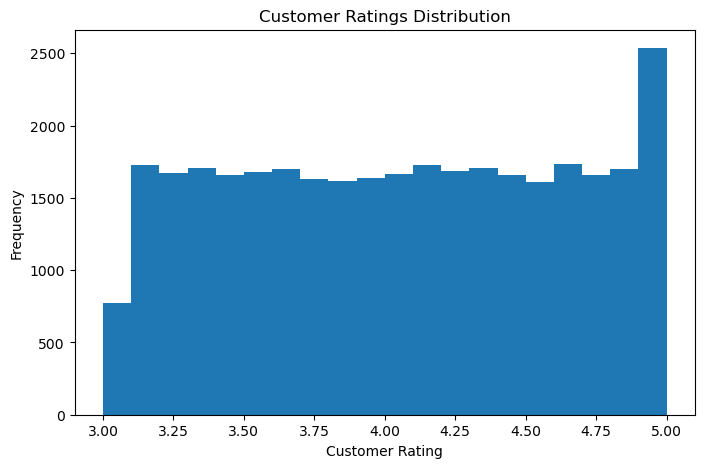

Average Customer Rating: 4.0


In [26]:
customer_rating = df["Customer Rating"].dropna()

plt.figure(figsize=(8,5))
plt.hist(customer_rating, bins=20)

plt.title("Customer Ratings Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Frequency")

plt.show()

print("Average Customer Rating:", round(customer_rating.mean(),2))

Customer Cancellation Reasons

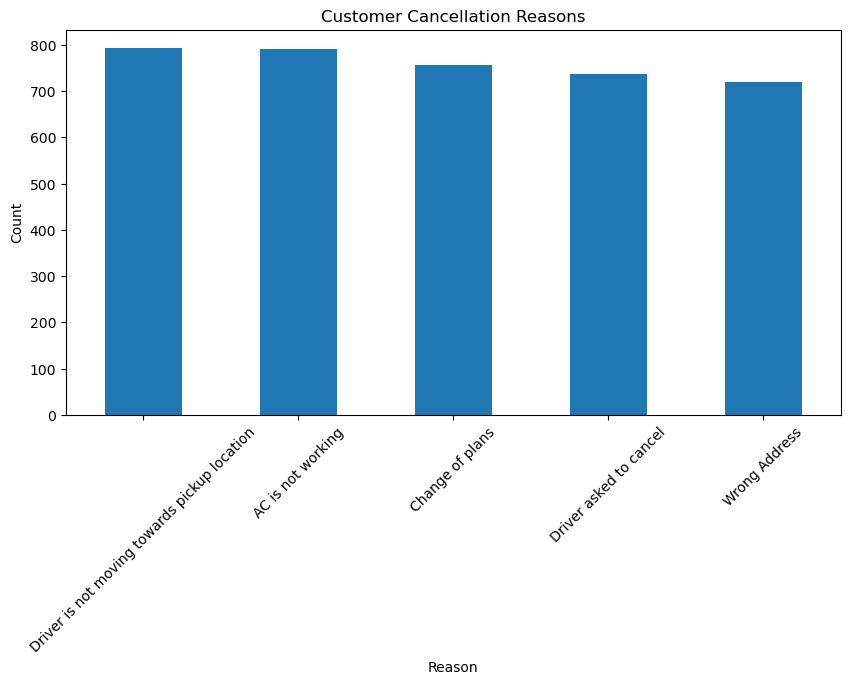

Reason for Cancelling by Customer
Driver is not moving towards pickup location    793
AC is not working                               792
Change of plans                                 756
Driver asked to cancel                          738
Wrong Address                                   720
Name: count, dtype: int64


In [29]:
customer_reason = (
    df["Reason for Cancelling by Customer"]
    .dropna()
    .value_counts()
)

plt.figure(figsize=(10,5))
customer_reason.plot(kind="bar")

plt.title("Customer Cancellation Reasons")
plt.xlabel("Reason")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

print(customer_reason)

Driver Cancellation Reasons

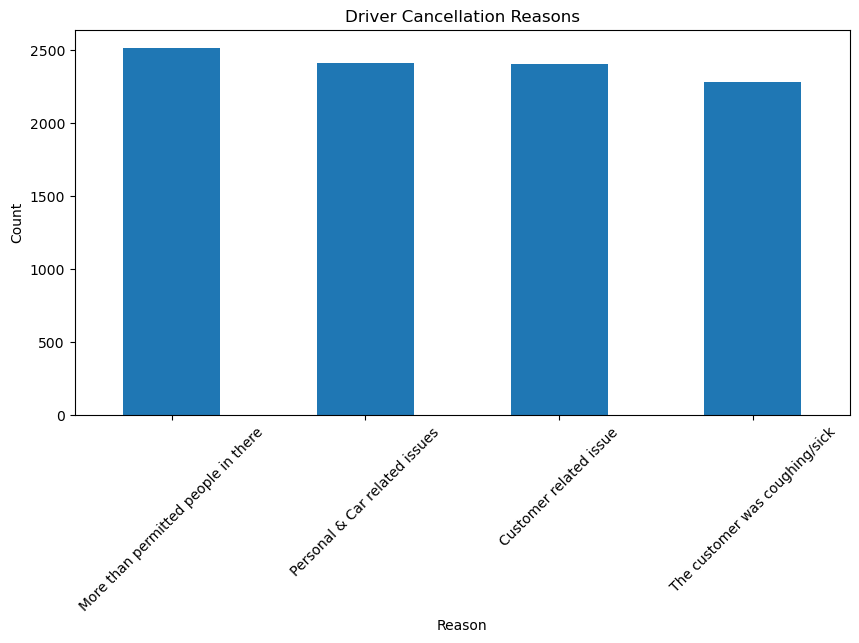

Reason for Cancelling by Driver
More than permitted people in there    2512
Personal & Car related issues          2413
Customer related issue                 2402
The customer was coughing/sick         2283
Name: count, dtype: int64


In [30]:
driver_reason = (
    df["Reason for Cancelling by Driver"]
    .dropna()
    .value_counts()
)

plt.figure(figsize=(10,5))
driver_reason.plot(kind="bar")

plt.title("Driver Cancellation Reasons")
plt.xlabel("Reason")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

print(driver_reason)

Incomplete Rides Analysis

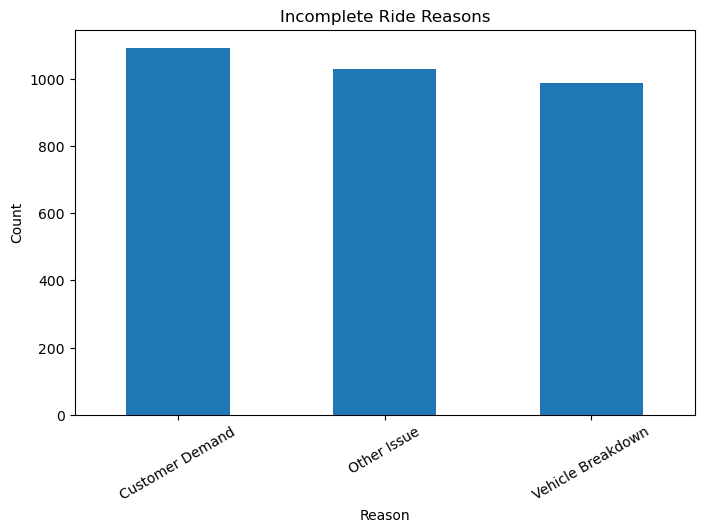

Incomplete Rides Reason
Customer Demand      1091
Other Issue          1029
Vehicle Breakdown     986
Name: count, dtype: int64


In [31]:
incomplete = (
    df["Incomplete Rides Reason"]
    .dropna()
    .value_counts()
)

plt.figure(figsize=(8,5))
incomplete.plot(kind="bar")

plt.title("Incomplete Ride Reasons")
plt.xlabel("Reason")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.show()

print(incomplete)

Top Pickup Locations

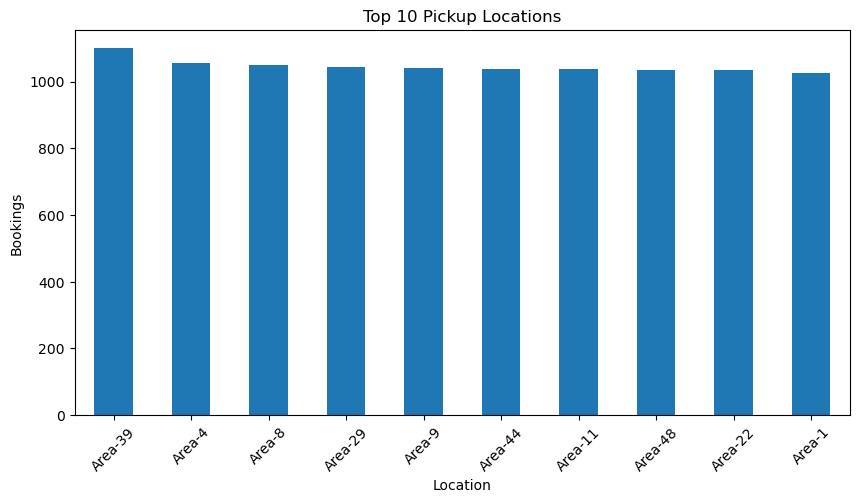

Pickup Location
Area-39    1100
Area-4     1057
Area-8     1049
Area-29    1045
Area-9     1040
Area-44    1039
Area-11    1038
Area-48    1035
Area-22    1034
Area-1     1027
Name: count, dtype: int64


In [32]:
pickup = df["Pickup Location"].value_counts().head(10)

plt.figure(figsize=(10,5))
pickup.plot(kind="bar")

plt.title("Top 10 Pickup Locations")
plt.xlabel("Location")
plt.ylabel("Bookings")

plt.xticks(rotation=45)

plt.show()

print(pickup)

Top Drop Locations

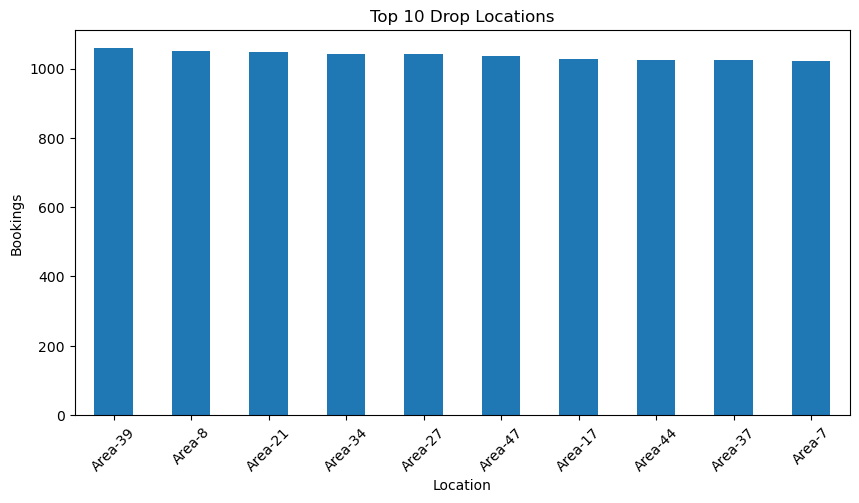

Drop Location
Area-39    1058
Area-8     1052
Area-21    1049
Area-34    1042
Area-27    1041
Area-47    1036
Area-17    1027
Area-44    1025
Area-37    1025
Area-7     1022
Name: count, dtype: int64


In [33]:
drop = df["Drop Location"].value_counts().head(10)

plt.figure(figsize=(10,5))
drop.plot(kind="bar")

plt.title("Top 10 Drop Locations")
plt.xlabel("Location")
plt.ylabel("Bookings")

plt.xticks(rotation=45)

plt.show()

print(drop)

Correlation Analysis

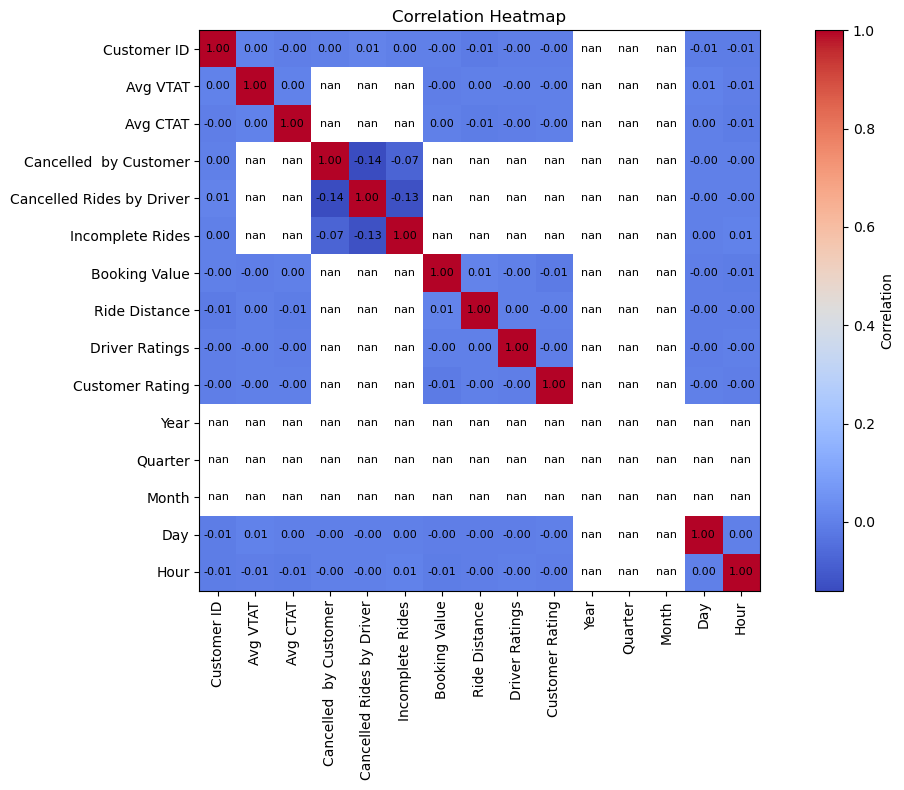

In [35]:
import matplotlib.pyplot as plt

# Select only numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Compute correlation matrix
corr = numeric_df.corr(numeric_only=True)

# Create heatmap
plt.figure(figsize=(12, 8))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")

# Axis labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add color bar
plt.colorbar(label="Correlation")

# Add correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Interpretation:
1. +1.00 → Strong positive correlation
2. 0.00 → No linear correlation
3. −1.00 → Strong negative correlation

1. Booking Value ↔ Ride Distance (typically positive).
2. Driver Ratings ↔ Customer Rating.
3. Avg CTAT ↔ Avg VTAT.
4. Booking Value ↔ Driver Ratings (often weak).